# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [ ]:

import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
!pip install pyarrow
# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv

print(os.getcwd())
print(os.listdir())

# 2. Acquire and load your primary dataset

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
response = requests.get(url)
#small comment just to have the commit change

/Users/rushana/Desktop/Data Science PP Rushan/notebooks/hw/hw_3
['hw_3.ipynb', 'hw_3_Rushan_Ajizu.ipynb']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

### *Source: OWID*


url =  "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"


### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [199]:
# 1. Inspect data structure using pandas methods
df_co2 = pd.read_csv(url)
df_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [200]:
df_co2.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

In [201]:
df_co2.shape

(50411, 79)

In [202]:
df_co2.head(3)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [203]:
df_co2.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017453e+07,3.300495e+11,7.890109,0.060013,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308433e+08,3.086383e+12,62.988171,0.123562,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291594e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.076250,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


In [204]:
# 2. Rename columns and select a clean subset
rename_dict = {
    "co2": "co2_emissions_mt",
    "gdp": "gdp_usd",
}
df_co2 = df_co2.rename(columns=rename_dict)


In [205]:
print(df.columns.tolist())


['country', 'year', 'iso_code', 'co2_emissions_mt', 'co2_per_capita', 'gdp_usd', 'population']


In [206]:
cols = ['country', 'year', 'iso_code', 'co2_emissions_mt', 'co2_per_capita', 'gdp_usd', 'population']
df = df[cols]


In [207]:
# 3. Filter row or column filters if necessary

# Removing aggregate regions (no ISO country code)
if 'iso_code' in df_co2.columns:
    df_co2 = df_co2[df_co2['iso_code'].notna()]
    df_co2 = df_co2[~df_co2['iso_code'].str.startswith('OWID')]
elif 'countryiso3code' in df_co2.columns:
    df_co2 = df_co2[df_co2['countryiso3code'].notna()]
    df_co2 = df_co2[~df_co2['countryiso3code'].str.startswith('OWID')]
else:
    pass
df_co2 = df_co2[~df_co2['iso_code'].str.startswith('OWID')]

In [208]:
# Filter rows with query
df_co2 = df_co2.query("year >= 2000 and co2_per_capita > 0 and gdp_usd  > 0")
df_co2.head(3)

,country,year,iso_code,population,gdp_usd,cement_co2,cement_co2_per_capita,co2_emissions_mt,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
250,Afghanistan,2000,AFG,20130334.0,1.128379e+10,0.010,0.001,1.047,-0.045,-4.078,...,NaN,0.078,0.0,0.001,0.001,0.0,16.009,2.603,NaN,NaN
251,Afghanistan,2001,AFG,20284303.0,1.102127e+10,0.007,0.000,1.069,0.022,2.098,...,NaN,0.077,0.0,0.001,0.001,0.0,14.895,2.701,NaN,NaN
252,Afghanistan,2002,AFG,21378123.0,1.880487e+10,0.011,0.001,1.341,0.272,25.439,...,NaN,0.077,0.0,0.001,0.001,0.0,20.037,3.044,NaN,NaN


In [209]:
# 4. Handle missing values (NaNs) if necessary
df_co2 = df_co2.dropna()
print(df_co2.shape)  #how many rows are left?

(986, 79)


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [210]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE

df_happiness = pd.read_parquet("../../../data/examples/week_5/world_happiness.parquet")
df_happiness.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   country_name                                143 non-null    object 
 1   ladder_score                                143 non-null    float64
 2   upperwhisker                                143 non-null    float64
 3   lowerwhisker                                143 non-null    float64
 4   explained_by:_log_gdp_per_capita            140 non-null    float64
 5   explained_by:_social_support                140 non-null    float64
 6   explained_by:_healthy_life_expectancy       140 non-null    float64
 7   explained_by:_freedom_to_make_life_choices  140 non-null    float64
 8   explained_by:_generosity                    140 non-null    float64
 9   explained_by:_perceptions_of_corruption     140 non-null    float64
 10  dystopia_+_res

In [211]:
# Rename columns to snake_case
happiness_rename = {
    "country_name": "country",
    "explained_by:_log_gdp_per_capita": "gdp_contribution",
    "explained_by:_social_support": "social_support",
    "explained_by:_healthy_life_expectancy": "life_expectancy",
    "explained_by:_freedom_to_make_life_choices": "freedom",
    "explained_by:_perceptions_of_corruption": "corruption",
    "explained_by:_generosity": "generosity"
}
df_happiness = df_happiness.rename(columns=happiness_rename)

# Drop columns you don't need
df_happiness = df_happiness[['country', 'ladder_score', 'social_support', 'life_expectancy', 'freedom']]


In [212]:
# 2. Merge your datasets on a common key
co2_latest = df[df['year'] == df['year'].max()]
df_merged = co2_latest.merge(df_happiness, on='country', how='inner')
print(df_merged.shape)




(41, 11)


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

Merge key: country
Observations: my merge retained 41 countries from the CO2 OWID dataset (43) and World Happiness (143), specifically 2024

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [213]:
# Apply groupby aggregation or implement one of the backup grouping strategies
'''I think I do not have a categorical column, so I'm going to check if happier countries have higher 
co2 emissions per capita.'''

df_merged['happiness_group'] = pd.cut(
    df_merged['ladder_score'],
    bins=3,
    labels=['low_happiness', 'medium_happiness', 'high_happiness']
)

df_merged['gdp_per_capita'] = df_merged['gdp_usd'] / df_merged['population']

grouped = df_merged.groupby('happiness_group')[['co2_per_capita', 'gdp_per_capita', 'freedom']].mean()
print(grouped)

grouped.style.format({
    'co2_per_capita': '{:.2f}',
    'gdp_per_capita': '${:,.0f}',
    'freedom': '{:.2f}'
})

                  co2_per_capita  gdp_per_capita   freedom
happiness_group                                           
low_happiness           7.290000    17812.548437  0.600833
medium_happiness        6.521304    32001.393983  0.636236
high_happiness          7.631933    49287.745067  0.758756


/var/folders/40/jw4n_6k56fv479pmbvl84x5h0000gn/T/ipykernel_31043/2521943414.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_merged.groupby('happiness_group')[['co2_per_capita', 'gdp_per_capita', 'freedom']].mean()


,co2_per_capita,gdp_per_capita,freedom
happiness_group,,,
low_happiness,7.29,"$17,813",0.60
medium_happiness,6.52,"$32,001",0.64
high_happiness,7.63,"$49,288",0.76


- *Extra Credit: Write your economic or policy related interpretation here*

High happiness countries have the most freedom (0.76) and highest GDP per capita. 
Freedom is measured by freedom to make life choices. This is the average response to the question (nationally): "Are you satisfied or dissatisfied with your freedom to choose what you do with your life?
The GDP and happiness pattern could be relatively expected. Richer countries with people who have relatively higher wealth per person would be happier. 

.... happier to have the greater freedom to pollute! 

Jokes aside, countries with the highest happiness per capita and highest GDP per capita seem to have the highest CO2 emission levels per capita. Of course, this is not necessarily an individual responsibility but it does show that higher development and wealth comes at a great cost for the environment. 

So the question is, can countries continue to maintain high happiness and freedom without the associated environmental burden? 

If we assume that Nordic countries are likely to be in the high happiness group, then maybe yes, as they are more focused on green energy transitions. Let's take a quick look:


In [214]:
nordic = ['Norway', 'Sweden', 'Denmark', 'Finland', 'Iceland']
df_merged[df_merged['country'].isin(nordic)][['country', 'ladder_score', 'co2_per_capita', 'gdp_per_capita', 'happiness_group']]


,country,ladder_score,co2_per_capita,gdp_per_capita,happiness_group
10,Denmark,7.5827,4.929,50725.738384,high_happiness
12,Finland,7.7407,6.525,40607.409810,high_happiness
27,Norway,7.3017,7.483,88390.412908,high_happiness
36,Sweden,7.3441,3.465,47124.891229,high_happiness


Assumption about right.
Sweden has the lowest CO2 per capita from the list (3.47t) despite being wealthy. High income doesn't have to mean high emissions. Norway is the outlier at 7.48t, likely due to its oil industry.


### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

In [223]:
df_merged['gdp_per_capita'] = df_merged['gdp_usd'] / df_merged['population']


Plot 1a) Freedom and Happiness

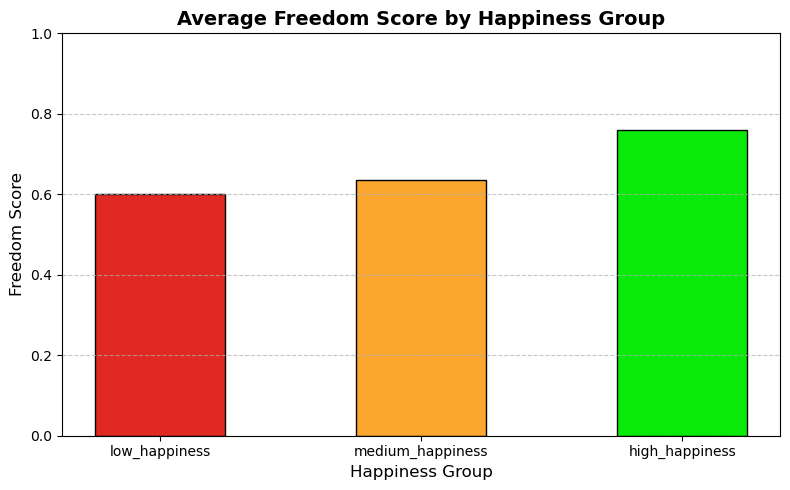

In [215]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    grouped.index,
    grouped['freedom'],
    color=["#e02922", "#fba62f", "#0aea0a"],
    edgecolor='black',
    width=0.5
)

ax.set_title('Average Freedom Score by Happiness Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Happiness Group', fontsize=12)
ax.set_ylabel('Freedom Score', fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Plot 1b) GDP p.c. and Happiness

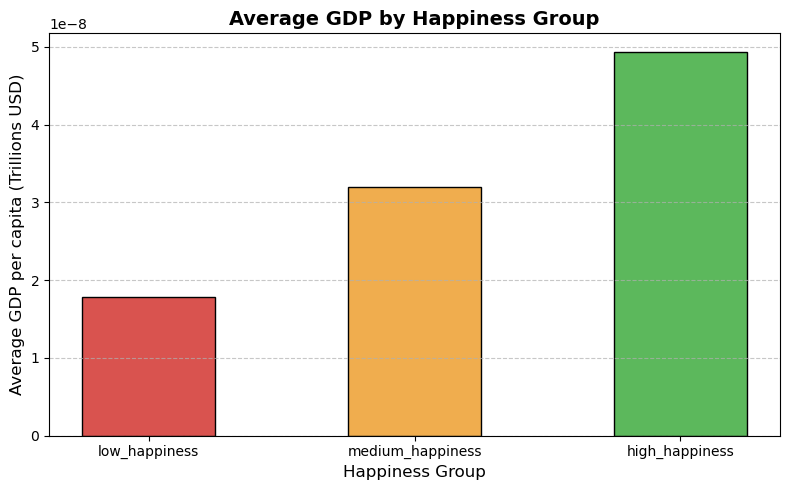

In [216]:
fig, ax = plt.subplots(figsize=(8, 5))

grouped['gdp_usd_trillions'] = grouped['gdp_per_capita'] / 1e12

ax.bar(
    grouped.index,
    grouped['gdp_usd_trillions'],
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    edgecolor='black',
    width=0.5
)

ax.set_title('Average GDP by Happiness Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Happiness Group', fontsize=12)
ax.set_ylabel('Average GDP per capita (Trillions USD)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Plot 1c) GDP and CO2 Emmissions p.c

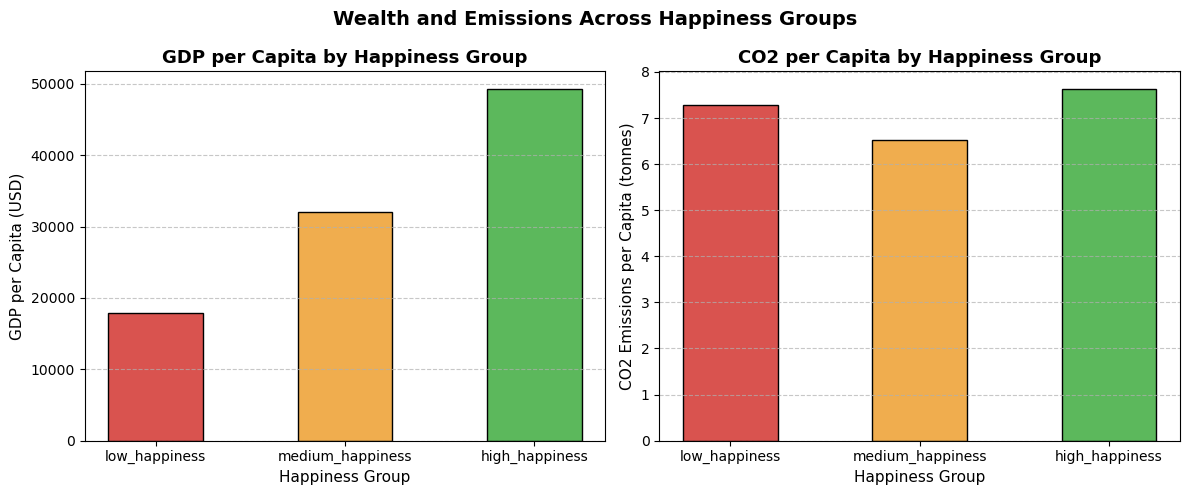

In [217]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#d9534f', '#f0ad4e', '#5cb85c']

ax1.bar(grouped.index, grouped['gdp_per_capita'], color=colors, edgecolor='black', width=0.5)
ax1.set_title('GDP per Capita by Happiness Group', fontsize=13, fontweight='bold')
ax1.set_xlabel('Happiness Group', fontsize=11)
ax1.set_ylabel('GDP per Capita (USD)', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.bar(grouped.index, grouped['co2_per_capita'], color=colors, edgecolor='black', width=0.5)
ax2.set_title('CO2 per Capita by Happiness Group', fontsize=13, fontweight='bold')
ax2.set_xlabel('Happiness Group', fontsize=11)
ax2.set_ylabel('CO2 Emissions per Capita (tonnes)', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Wealth and Emissions Across Happiness Groups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Plot 2a: Scatter plot for GDP p.c. and happiness

/var/folders/40/jw4n_6k56fv479pmbvl84x5h0000gn/T/ipykernel_31043/3937419081.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(x_range, model.params[0] + model.params[1] * x_range, color='#d9534f', linewidth=2, label='Line of Best Fit')


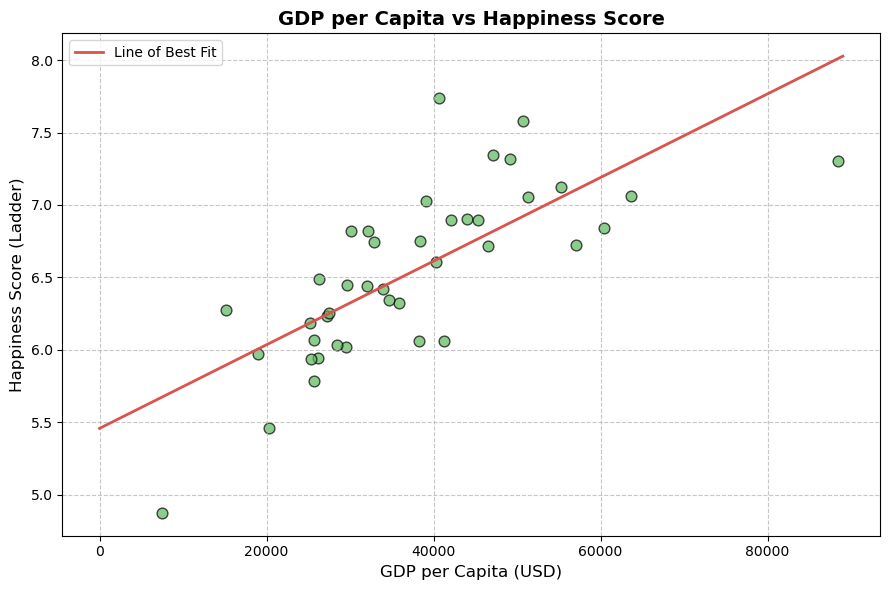

                            OLS Regression Results                            
Dep. Variable:           ladder_score   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     46.00
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.27e-08
Time:                        16:27:34   Log-Likelihood:                -19.479
No. Observations:                  41   AIC:                             42.96
Df Residuals:                      39   BIC:                             46.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.4569      0.171     31.

In [218]:
# Fit a simple linear regression and overlay the line of best fit

import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_merged['gdp_per_capita'], df_merged['ladder_score'], 
           color='#5cb85c', edgecolor='black', alpha=0.7, s=60)

# Regression line
X = sm.add_constant(df_merged['gdp_per_capita'])
model = sm.OLS(df_merged['ladder_score'], X).fit()
x_range = pd.Series(range(0, int(df_merged['gdp_per_capita'].max()) + 1000, 1000))
ax.plot(x_range, model.params[0] + model.params[1] * x_range, color='#d9534f', linewidth=2, label='Line of Best Fit')

ax.set_title('GDP per Capita vs Happiness Score', fontsize=14, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)', fontsize=12)
ax.set_ylabel('Happiness Score (Ladder)', fontsize=12)
ax.legend()
ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(model.summary())


Plot 2b) GDP and CO2 emmissions p.c., based on happiness scores

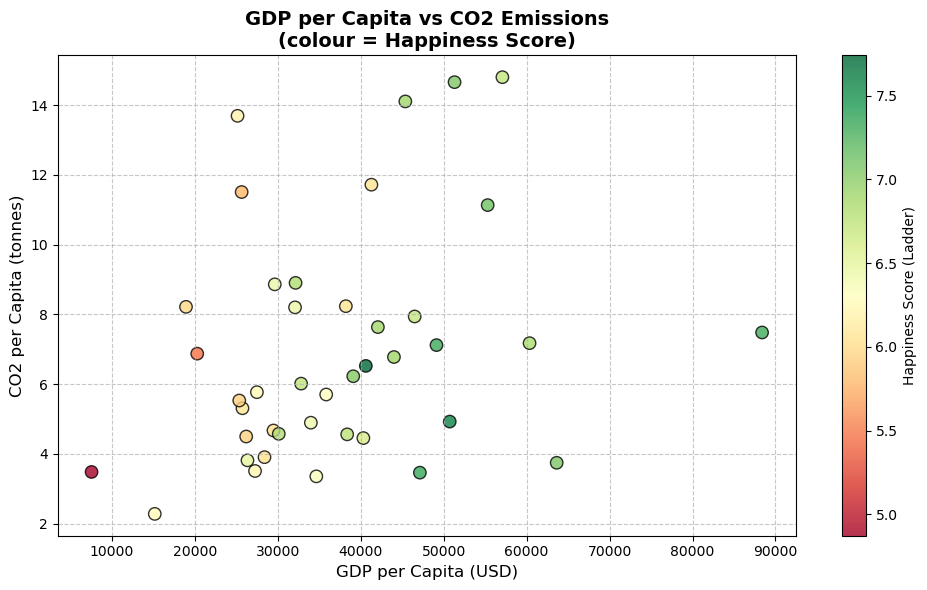

In [219]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_merged['gdp_per_capita'],
    df_merged['co2_per_capita'],
    c=df_merged['ladder_score'],
    cmap='RdYlGn',
    s=80,
    edgecolor='black',
    alpha=0.8
)

plt.colorbar(scatter, label='Happiness Score (Ladder)')

ax.set_title('GDP per Capita vs CO2 Emissions\n(colour = Happiness Score)', fontsize=14, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)', fontsize=12)
ax.set_ylabel('CO2 per Capita (tonnes)', fontsize=12)
ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


- *Extra Credit: Write your visualization and regression interpretations here*


As someone who struggles greatly with statistics, it took me a while and lots of questions to Claude to come up with a technical interpretation. Here it is:

Plot 2a) For the regression results of GDP per capita and happiness, R² = 0.541, which means that GDP explains 54% of happiness. The remaining percentage could be other factors like freedom or institutional gaps.　The slope of the line, which is = 0.0000289, can point to the correlation that richer = happier, but the effect is small when considered per dollar.  every $1,000, it's only +0.029 happiness points. Still, in statistical terms this effect is very significant (p < 0.001). This suggests that the relationship is unlikely to be due to chance (also confirmed by P-value = 0.000).

Plot 2b) There is some, but a weak correlation between GDP per capita and CO2 emmissions per capita. While wealther countries have higher emissions, this comes with variations and outliers. Some countries that are not the wealthiest but have high emissions are likely to be those with strong oil-industries (e.g. Kuwait). Also, Norway, despite its oil industry, has controlled its emissions, so it probably sits at the far right.


### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.